# 02 — Bias Detection & Fairness Analysis
**NovaCred Credit Application Governance Audit**  

This notebook performs a structured fairness audit covering:

1. **Gender Disparate Impact** — four-fifths (80%) rule  
2. **Age-based discrimination** — approval rates across age cohorts  
3. **Proxy discrimination analysis** — geographic attributes (ZIP code) as proxies for protected characteristics  
4. **Interaction effects** — gender × age  
5. **Interest rate disparities** — differential pricing for approved applicants  
6. **Statistical significance testing** — χ² and Mann-Whitney U tests



## 0. Setup & Load Clean Data

In [1]:
import json
import warnings
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, pointbiserialr

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
SEED = 42

print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ── Load and re-prepare data from raw source
# (mirrors cleaning steps from notebook 01; use clean CSV if available)
import os

CLEAN_PATH = '../data/clean_credit_applications.csv'
RAW_PATH   = '../data/raw_credit_applications.json'

if os.path.exists(CLEAN_PATH):
    df = pd.read_csv(CLEAN_PATH)
    print(f'Loaded clean dataset: {df.shape}')
else:
    # ── inline flattening (fallback if notebook 01 was not run first)
    print('Clean CSV not found — loading from raw JSON...')
    DATE_FORMATS = [
        '%Y-%m-%d', '%d/%m/%Y', '%m/%d/%Y', '%Y/%m/%d'
    ]
    GENDER_MAP = {'Male':'Male','M':'Male','Female':'Female','F':'Female'}

    def parse_dob(val):
        if pd.isna(val) or val == '':
            return pd.NaT
        for fmt in DATE_FORMATS:
            try:
                return datetime.strptime(str(val), fmt)
            except ValueError:
                pass
        return pd.NaT

    with open(RAW_PATH) as f:
        raw = json.load(f)

    records = []
    for rec in raw:
        ai  = rec.get('applicant_info', {}) or {}
        fin = rec.get('financials', {})      or {}
        dec = rec.get('decision', {})        or {}
        sb  = rec.get('spending_behavior', []) or []
        records.append({
            '_id'                   : rec.get('_id'),
            'gender'                : GENDER_MAP.get(ai.get('gender')),
            'date_of_birth_raw'     : ai.get('date_of_birth'),
            'zip_code'              : ai.get('zip_code'),
            'annual_income'         : pd.to_numeric(fin.get('annual_income'), errors='coerce'),
            'credit_history_months' : fin.get('credit_history_months'),
            'debt_to_income'        : fin.get('debt_to_income'),
            'savings_balance'       : fin.get('savings_balance'),
            'loan_approved'         : dec.get('loan_approved'),
            'interest_rate'         : dec.get('interest_rate'),
            'approved_amount'       : dec.get('approved_amount'),
            'rejection_reason'      : dec.get('rejection_reason'),
            'spend_categories'      : [s.get('category') for s in sb],
        })

    df = pd.DataFrame(records).drop_duplicates(subset='_id', keep='first')
    df['date_of_birth'] = df['date_of_birth_raw'].apply(parse_dob)
    REF = datetime(2024, 1, 1)
    df['age'] = ((REF - pd.to_datetime(df['date_of_birth'])).dt.days / 365.25).round(1)
    df.loc[df['credit_history_months'] < 0, 'credit_history_months'] = np.nan
    print(f'Raw dataset flattened and cleaned: {df.shape}')

# Ensure age and spend columns exist
if 'age' not in df.columns and 'date_of_birth' in df.columns:
    REF = datetime(2024, 1, 1)
    df['age'] = ((REF - pd.to_datetime(df['date_of_birth'])).dt.days / 365.25).round(1)

print(f'Working dataset: {len(df)} records')

Loaded clean dataset: (500, 26)
Working dataset: 500 records


---
## 1. Baseline Approval Rates

Total applications : 500
Approved           : 292 (58.4%)
Denied             : 208   (41.6%)


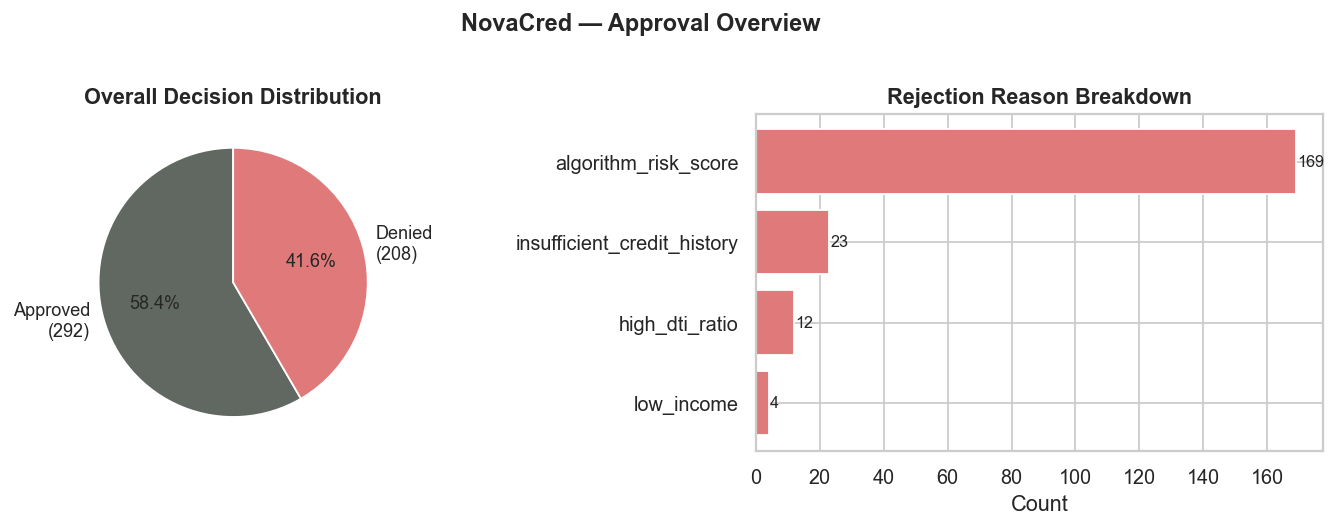

In [18]:
total      = len(df)
n_approved = df['loan_approved'].sum()
n_denied   = total - n_approved
overall_rate = n_approved / total

print(f'Total applications : {total}')
print(f'Approved           : {n_approved} ({overall_rate*100:.1f}%)')
print(f'Denied             : {n_denied}   ({(1-overall_rate)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# pie
axes[0].pie([n_approved, n_denied],
            labels=[f'Approved\n({n_approved})', f'Denied\n({n_denied})'],
            colors=["#616861","#E07A7A"],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize':10})
axes[0].set_title('Overall Decision Distribution', fontweight='bold')

# rejection reasons
reasons = df[df['loan_approved']==False]['rejection_reason'].value_counts()
axes[1].barh(reasons.index[::-1], reasons.values[::-1],
             color="#E07A7A", edgecolor='white')
for i, v in enumerate(reasons.values[::-1]):
    axes[1].text(v+0.5, i, str(v), va='center', fontsize=9)
axes[1].set_title('Rejection Reason Breakdown', fontweight='bold')
axes[1].set_xlabel('Count')

plt.suptitle('NovaCred — Approval Overview', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/fig_approval_overview.png', dpi=130)
plt.show()

---
## 2. Gender Disparate Impact (Four-Fifths Rule)

$$DI = \frac{\text{Approval rate — unprivileged group (Female)}}{\text{Approval rate — privileged group (Male)}}$$

> A DI ratio below **0.8** (i.e., 80%) signals potential disparate impact and triggers the four-fifths rule (29 CFR § 1607.4D).

In [9]:
# Only gender-known applicants
df_g = df[df['gender'].isin(['Male','Female'])].copy()
gender_stats = (
    df_g.groupby('gender')['loan_approved']
        .agg(total='count', approved='sum')
        .assign(approval_rate=lambda x: x['approved']/x['total'])
)

print('=== Gender Approval Statistics ===')
print(gender_stats.to_string())

male_rate   = gender_stats.loc['Male',   'approval_rate']
female_rate = gender_stats.loc['Female', 'approval_rate']
DI_RATIO    = female_rate / male_rate

print(f'\nDisparate Impact Ratio (Female / Male) = {DI_RATIO:.4f}')
print(f'Four-fifths threshold                  = 0.8000')
print(f'Result: {"⚠️  DI < 0.8 — POTENTIAL DISPARATE IMPACT DETECTED" if DI_RATIO < 0.8 else "✓ DI ≥ 0.8 — within acceptable range"}')

=== Gender Approval Statistics ===
        total  approved  approval_rate
gender                                
Female    251       127       0.505976
Male      247       163       0.659919

Disparate Impact Ratio (Female / Male) = 0.7667
Four-fifths threshold                  = 0.8000
Result: ⚠️  DI < 0.8 — POTENTIAL DISPARATE IMPACT DETECTED


In [10]:
# ── χ² test for statistical significance
contingency = pd.crosstab(df_g['gender'], df_g['loan_approved'])
chi2, p_val, dof, expected = chi2_contingency(contingency)

print(f'χ² statistic : {chi2:.4f}')
print(f'p-value      : {p_val:.6f}')
print(f'Degrees of freedom : {dof}')
print(f'Conclusion: {"Statistically significant (p < 0.05)" if p_val < 0.05 else "Not statistically significant (p ≥ 0.05)"}')

χ² statistic : 11.5053
p-value      : 0.000694
Degrees of freedom : 1
Conclusion: Statistically significant (p < 0.05)


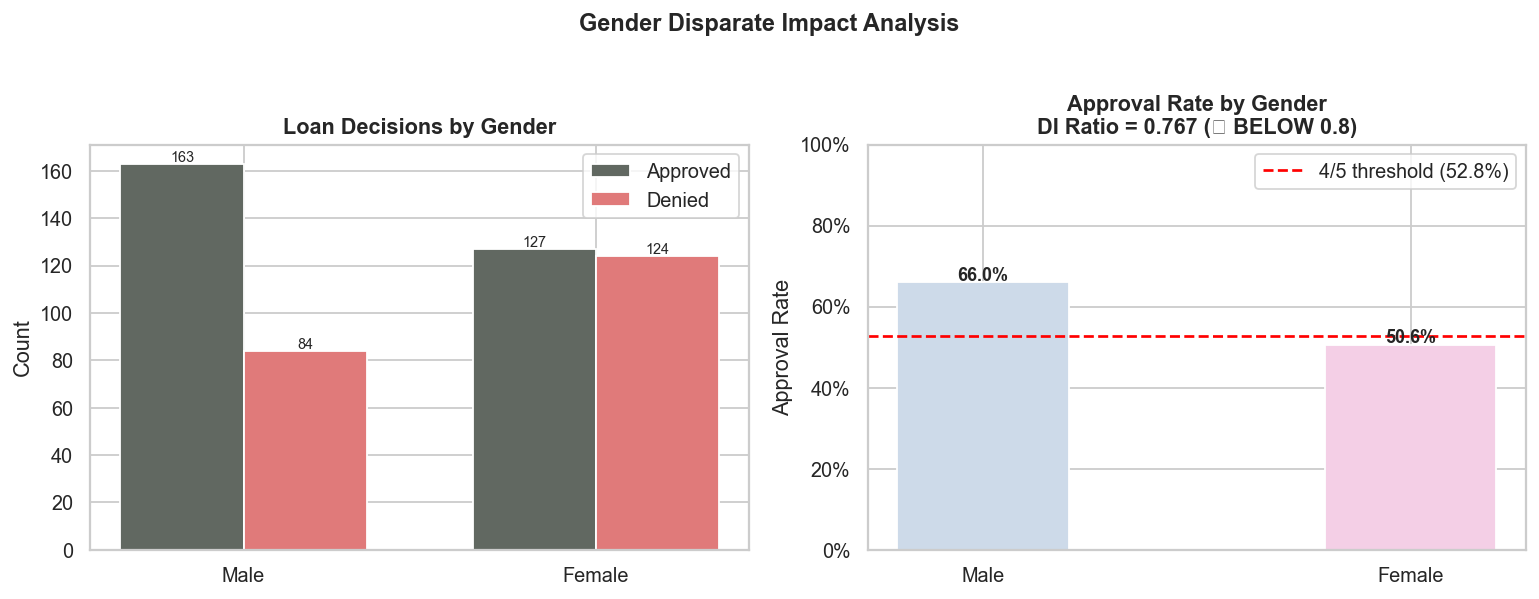


>>> KEY FINDING: DI Ratio = 0.7667  |  p-value = 0.0007  |  DISPARATE IMPACT CONFIRMED


In [19]:
# ── visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ── left: grouped bar chart
x = np.arange(2)
width = 0.35
approved_counts = [gender_stats.loc['Male','approved'], gender_stats.loc['Female','approved']]
denied_counts   = [gender_stats.loc['Male','total']-gender_stats.loc['Male','approved'],
                   gender_stats.loc['Female','total']-gender_stats.loc['Female','approved']]

b1 = axes[0].bar(x - width/2, approved_counts, width, label='Approved', color="#616861", edgecolor='white')
b2 = axes[0].bar(x + width/2, denied_counts,   width, label='Denied',   color="#E07A7A", edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Male', 'Female'])
axes[0].set_title('Loan Decisions by Gender', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].legend()
for b in list(b1) + list(b2):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+1,
                 str(int(b.get_height())), ha='center', fontsize=8)

# ── right: approval rate bars with DI threshold line
rates = [male_rate, female_rate]
bar_colors = ["#cddae9", "#f4cfe6"]
bars = axes[1].bar(['Male','Female'], rates, color=bar_colors, width=0.4, edgecolor='white')
for b, v in zip(bars, rates):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.005,
                 f'{v*100:.1f}%', ha='center', fontweight='bold', fontsize=10)

# Draw DI threshold line at male_rate * 0.8
threshold_line = male_rate * 0.8
axes[1].axhline(threshold_line, color='red', linestyle='--', linewidth=1.5,
                label=f'4/5 threshold ({threshold_line*100:.1f}%)')
axes[1].set_title(f'Approval Rate by Gender\nDI Ratio = {DI_RATIO:.3f} '
                  f'({"⚠ BELOW 0.8" if DI_RATIO < 0.8 else "✓ above 0.8"})',
                  fontweight='bold')
axes[1].set_ylabel('Approval Rate')
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
axes[1].legend()

plt.suptitle('Gender Disparate Impact Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/fig_gender_di.png', dpi=130)
plt.show()

print(f'\n>>> KEY FINDING: DI Ratio = {DI_RATIO:.4f}  |  '
      f'p-value = {p_val:.4f}  |  '
      f'{"DISPARATE IMPACT CONFIRMED" if DI_RATIO < 0.8 and p_val < 0.05 else "Within acceptable range"}')

---
## 3. Age-Based Discrimination Analysis

In [20]:
# Define age cohorts aligned with common discrimination law categories
df_age = df[df['age'].notna() & (df['age'] >= 18) & (df['age'] <= 100)].copy()

bins   = [18, 30, 40, 50, 60, 101]
labels = ['18–29', '30–39', '40–49', '50–59', '60+']
df_age['age_cohort'] = pd.cut(df_age['age'], bins=bins, labels=labels, right=False)

age_stats = (
    df_age.groupby('age_cohort', observed=True)['loan_approved']
          .agg(total='count', approved='sum')
          .assign(approval_rate=lambda x: x['approved']/x['total'])
)

print('=== Age Cohort Approval Statistics ===')
print(age_stats.to_string())

=== Age Cohort Approval Statistics ===
            total  approved  approval_rate
age_cohort                                
18–29         115        48       0.417391
30–39         170       105       0.617647
40–49         124        86       0.693548
50–59          56        30       0.535714
60+            31        20       0.645161


In [21]:
# Disparate Impact: youngest vs oldest cohort
youngest_rate = age_stats.iloc[0]['approval_rate']
oldest_rate   = age_stats.iloc[-1]['approval_rate']

# Using 30–39 as "privileged" (typically highest earner age)
peak_age_rate = age_stats.loc['30–39','approval_rate'] if '30–39' in age_stats.index else age_stats['approval_rate'].max()
di_age_young  = youngest_rate / peak_age_rate
di_age_old    = oldest_rate   / peak_age_rate

print(f'DI (18–29 vs 30–39): {di_age_young:.4f}  -> {"⚠ < 0.8" if di_age_young < 0.8 else "✓"}')
print(f'DI (60+   vs 30–39): {di_age_old:.4f}   -> {"⚠ < 0.8" if di_age_old < 0.8 else "✓"}')

# Point-biserial correlation: age vs approval
valid = df_age[df_age['loan_approved'].notna()]
r_pb, p_pb = pointbiserialr(valid['loan_approved'].astype(int), valid['age'])
print(f'\nPoint-biserial r (age ~ approval): {r_pb:.4f},  p = {p_pb:.6f}')

DI (18–29 vs 30–39): 0.6758  -> ⚠ < 0.8
DI (60+   vs 30–39): 1.0445   -> ✓

Point-biserial r (age ~ approval): 0.1241,  p = 0.005638


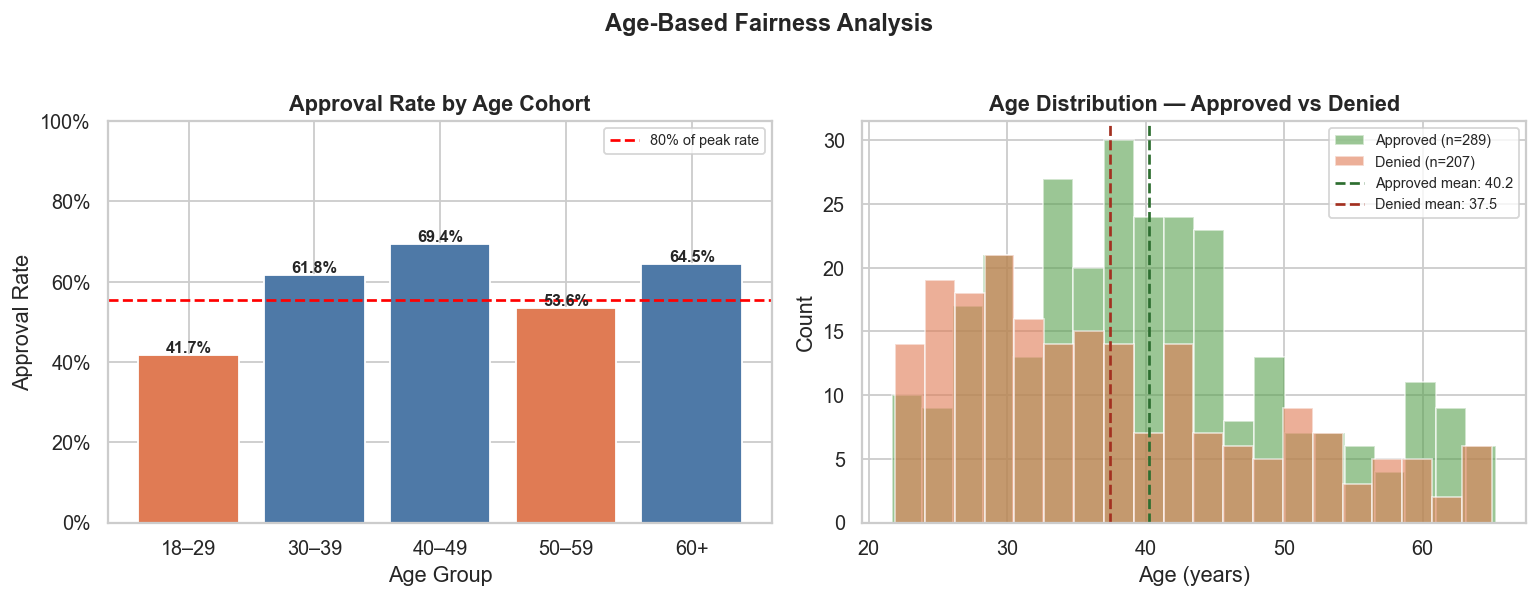

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ── approval rate by cohort
cohort_labels = age_stats.index.tolist()
rates         = age_stats['approval_rate'].values
bar_cols      = ['#e07b54' if r < 0.8*rates.max() else '#4e79a7' for r in rates]

bars = axes[0].bar(cohort_labels, rates, color=bar_cols, edgecolor='white')
axes[0].axhline(rates.max()*0.8, color='red', linestyle='--', linewidth=1.5,
                label='80% of peak rate')
for b, v in zip(bars, rates):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.005,
                 f'{v*100:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Approval Rate by Age Cohort', fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Approval Rate')
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y*100:.0f}%'))
axes[0].legend(fontsize=8)

# ── age distribution approved vs denied
approved_ages = df_age[df_age['loan_approved']==True]['age'].dropna()
denied_ages   = df_age[df_age['loan_approved']==False]['age'].dropna()
axes[1].hist(approved_ages, bins=20, alpha=0.6, color='#59a14f', label=f'Approved (n={len(approved_ages)})')
axes[1].hist(denied_ages,   bins=20, alpha=0.6, color='#e07b54', label=f'Denied (n={len(denied_ages)})')
axes[1].axvline(approved_ages.mean(), color='#2d6e30', linestyle='--', linewidth=1.5,
                label=f'Approved mean: {approved_ages.mean():.1f}')
axes[1].axvline(denied_ages.mean(),   color='#a33020', linestyle='--', linewidth=1.5,
                label=f'Denied mean: {denied_ages.mean():.1f}')
axes[1].set_title('Age Distribution — Approved vs Denied', fontweight='bold')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8)

plt.suptitle('Age-Based Fairness Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/fig_age_bias.png', dpi=130)
plt.show()

---
## 4. Proxy Discrimination — ZIP Code as Geographic Proxy

In [23]:
# NovaCred data has two dominant ZIP code clusters
# 100xx = Manhattan/NYC area  |  902xx = South Los Angeles area
# Geographic clustering can serve as a proxy for race/ethnicity (redlining risk)

df_zip = df[df['zip_code'].notna()].copy()
df_zip['zip_prefix'] = df_zip['zip_code'].astype(str).str[:3]

zip_stats = (
    df_zip.groupby('zip_prefix')['loan_approved']
          .agg(total='count', approved='sum')
          .assign(approval_rate=lambda x: x['approved']/x['total'])
          .sort_values('total', ascending=False)
)

print('=== ZIP Code Prefix — Approval Rates ===')
print(zip_stats[zip_stats['total'] >= 10].to_string())

=== ZIP Code Prefix — Approval Rates ===
            total  approved  approval_rate
zip_prefix                                
100           251       162       0.645418
902           230       119       0.517391
300            18        10       0.555556


In [24]:
# Compare the two main clusters
nyc_prefix = '100'
la_prefix  = '902'

nyc_rate = zip_stats.loc[nyc_prefix, 'approval_rate'] if nyc_prefix in zip_stats.index else None
la_rate  = zip_stats.loc[la_prefix,  'approval_rate'] if la_prefix  in zip_stats.index else None

if nyc_rate and la_rate:
    privileged_zip_rate   = max(nyc_rate, la_rate)
    unprivileged_zip_rate = min(nyc_rate, la_rate)
    di_zip = unprivileged_zip_rate / privileged_zip_rate
    print(f'NYC (100xx) approval rate : {nyc_rate*100:.1f}%')
    print(f'LA  (902xx) approval rate : {la_rate*100:.1f}%')
    print(f'ZIP-based DI ratio        : {di_zip:.4f}  -> {"⚠ < 0.8" if di_zip < 0.8 else "✓"}')

    # χ² test
    df_two_zip = df_zip[df_zip['zip_prefix'].isin([nyc_prefix, la_prefix])]
    ct = pd.crosstab(df_two_zip['zip_prefix'], df_two_zip['loan_approved'])
    chi2_zip, p_zip, _, _ = chi2_contingency(ct)
    print(f'χ² = {chi2_zip:.4f},  p = {p_zip:.6f}  -> {"Significant" if p_zip < 0.05 else "Not significant"}')

NYC (100xx) approval rate : 64.5%
LA  (902xx) approval rate : 51.7%
ZIP-based DI ratio        : 0.8016  -> ✓
χ² = 7.5802,  p = 0.005901  -> Significant


In [25]:
# ── also examine correlation: ZIP cluster vs applicant financials (to test if geographic
# differences correlate with income, suggesting economic stratification)

df_zip['nyc_cluster'] = df_zip['zip_prefix'] == nyc_prefix

income_nyc = df_zip[df_zip['nyc_cluster']==True]['annual_income'].dropna()
income_la  = df_zip[df_zip['nyc_cluster']==False]['annual_income'].dropna()

u_stat, p_income = mannwhitneyu(income_nyc, income_la, alternative='two-sided')

print(f'Median income NYC cluster : ${income_nyc.median():,.0f}')
print(f'Median income LA  cluster : ${income_la.median():,.0f}')
print(f'Mann-Whitney U p-value    : {p_income:.6f}  -> {"Income differs significantly" if p_income < 0.05 else "No significant income difference"}')

Median income NYC cluster : $80,500
Median income LA  cluster : $83,500
Mann-Whitney U p-value    : 0.284670  -> No significant income difference


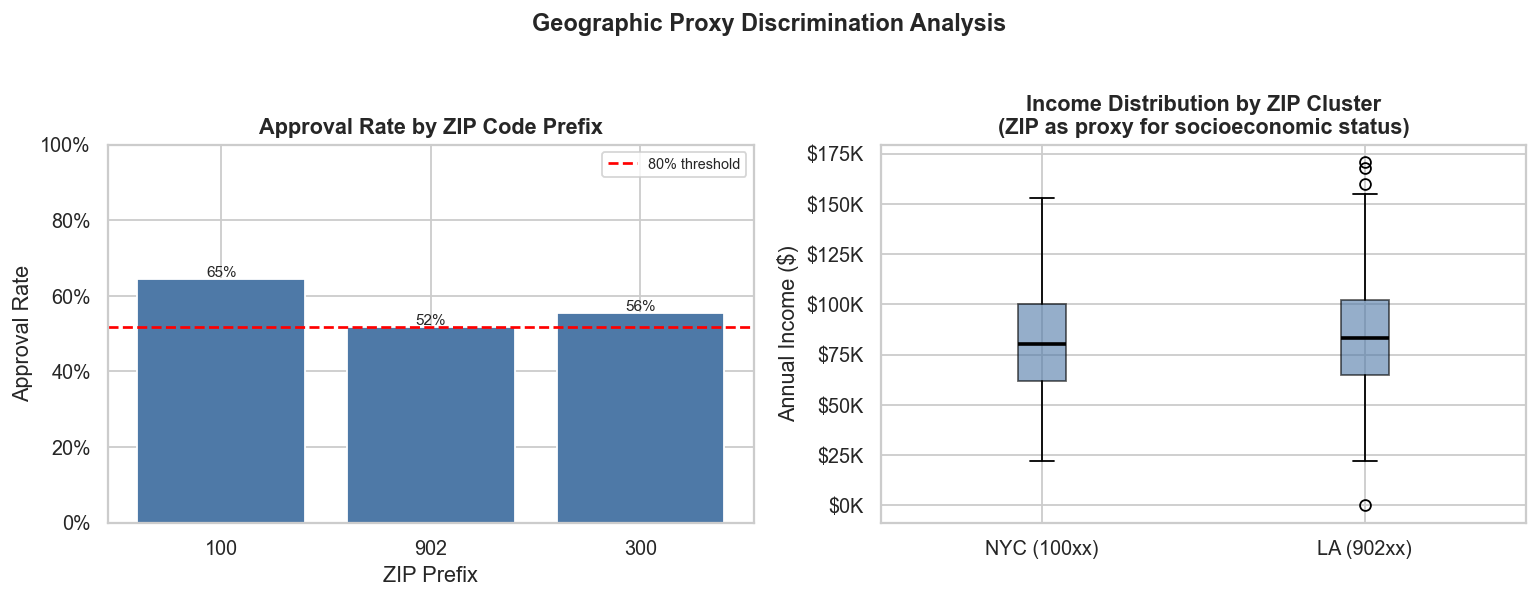

In [26]:
# ── visualise geographic proxy effect
main_zips = zip_stats[zip_stats['total'] >= 15]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# approval rates by prefix
highlight = ['#e07b54' if r < 0.8*main_zips['approval_rate'].max() else '#4e79a7'
             for r in main_zips['approval_rate']]
axes[0].bar(main_zips.index, main_zips['approval_rate'],
            color=highlight, edgecolor='white')
axes[0].axhline(main_zips['approval_rate'].max()*0.8,
                color='red', linestyle='--', linewidth=1.5, label='80% threshold')
for i, (idx, row) in enumerate(main_zips.iterrows()):
    axes[0].text(i, row['approval_rate']+0.005,
                 f"{row['approval_rate']*100:.0f}%", ha='center', fontsize=8.5)
axes[0].set_title('Approval Rate by ZIP Code Prefix', fontweight='bold')
axes[0].set_xlabel('ZIP Prefix')
axes[0].set_ylabel('Approval Rate')
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y*100:.0f}%'))
axes[0].legend(fontsize=8)

# income distribution by cluster
axes[1].boxplot([income_nyc, income_la], labels=['NYC (100xx)', 'LA (902xx)'],
                patch_artist=True,
                boxprops=dict(facecolor='#4e79a7', alpha=0.6),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title('Income Distribution by ZIP Cluster\n(ZIP as proxy for socioeconomic status)',
                  fontweight='bold')
axes[1].set_ylabel('Annual Income ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'${y/1000:.0f}K'))

plt.suptitle('Geographic Proxy Discrimination Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/fig_zip_proxy.png', dpi=130)
plt.show()

---
## 5. Interaction Effects — Gender × Age

In [27]:
df_inter = df[
    df['gender'].isin(['Male','Female']) &
    df['age'].notna() &
    (df['age'] >= 18) & (df['age'] <= 100)
].copy()

bins   = [18, 30, 45, 60, 101]
labels = ['18–29', '30–44', '45–59', '60+']
df_inter['age_band'] = pd.cut(df_inter['age'], bins=bins, labels=labels, right=False)

interaction = (
    df_inter.groupby(['gender','age_band'], observed=True)['loan_approved']
             .agg(total='count', approved='sum')
             .assign(approval_rate=lambda x: x['approved']/x['total'])
             .reset_index()
)

print('=== Gender × Age Interaction ===')
pivot = interaction.pivot(index='age_band', columns='gender', values='approval_rate')
print((pivot * 100).round(1).to_string())

=== Gender × Age Interaction ===
gender    Female  Male
age_band              
18–29       31.1  53.7
30–44       57.7  70.6
45–59       54.0  66.0
60+         60.0  68.8


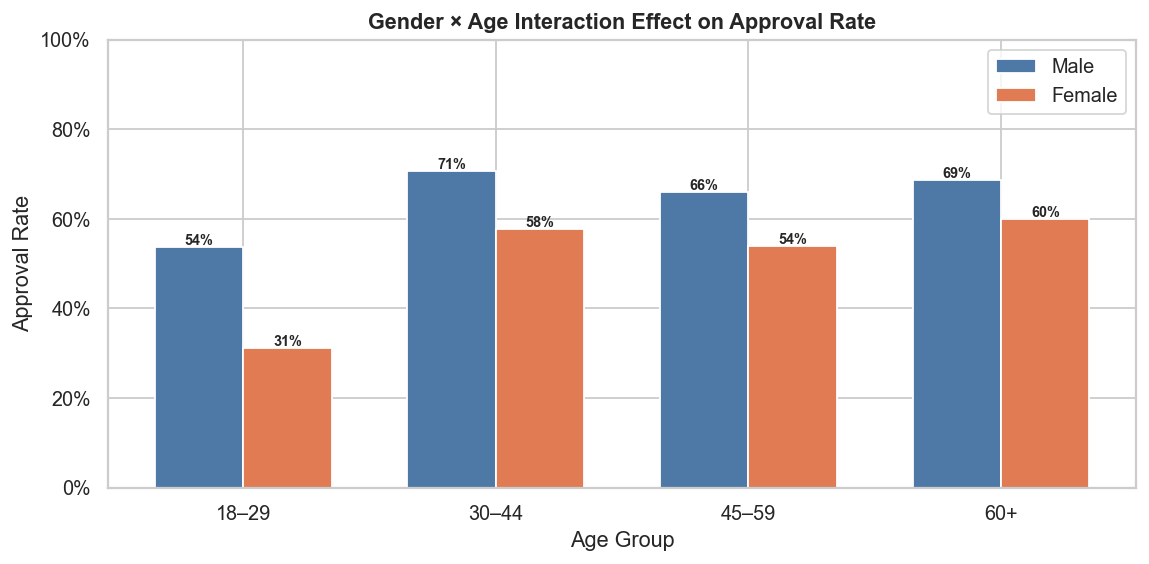

In [28]:
fig, ax = plt.subplots(figsize=(9, 4.5))

x = np.arange(len(labels))
width = 0.35

male_rates   = [interaction[(interaction['gender']=='Male')   & (interaction['age_band']==b)]['approval_rate'].values[0]
                if len(interaction[(interaction['gender']=='Male') & (interaction['age_band']==b)]) > 0 else 0
                for b in labels]
female_rates = [interaction[(interaction['gender']=='Female') & (interaction['age_band']==b)]['approval_rate'].values[0]
                if len(interaction[(interaction['gender']=='Female') & (interaction['age_band']==b)]) > 0 else 0
                for b in labels]

b1 = ax.bar(x - width/2, male_rates,   width, label='Male',   color='#4e79a7', edgecolor='white')
b2 = ax.bar(x + width/2, female_rates, width, label='Female', color='#e07b54', edgecolor='white')

for b, v in list(zip(b1, male_rates)) + list(zip(b2, female_rates)):
    ax.text(b.get_x()+b.get_width()/2, v+0.005,
            f'{v*100:.0f}%', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('Age Group')
ax.set_ylabel('Approval Rate')
ax.set_title('Gender × Age Interaction Effect on Approval Rate', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y*100:.0f}%'))
ax.legend()

plt.tight_layout()
plt.savefig('../data/fig_gender_age_interaction.png', dpi=130)
plt.show()

---
## 6. Interest Rate Disparities (Differential Pricing)

In [29]:
df_approved = df[
    (df['loan_approved'] == True) &
    df['interest_rate'].notna() &
    df['gender'].isin(['Male','Female'])
].copy()

rate_by_gender = df_approved.groupby('gender')['interest_rate'].describe().round(3)
print('=== Interest Rate Distribution by Gender (Approved Applicants Only) ===')
print(rate_by_gender.to_string())

male_rates_ir   = df_approved[df_approved['gender']=='Male']['interest_rate']
female_rates_ir = df_approved[df_approved['gender']=='Female']['interest_rate']

u_stat_ir, p_ir = mannwhitneyu(male_rates_ir, female_rates_ir, alternative='two-sided')
print(f'\nMann-Whitney U test (Male vs Female interest rates):')
print(f'  Male median rate   : {male_rates_ir.median():.2f}%')
print(f'  Female median rate : {female_rates_ir.median():.2f}%')
print(f'  p-value            : {p_ir:.6f}  -> {"Significant pricing disparity" if p_ir < 0.05 else "No significant difference"}')

=== Interest Rate Distribution by Gender (Approved Applicants Only) ===
        count   mean    std  min  25%  50%   75%  max
gender                                               
Female  127.0  4.488  1.193  2.5  3.4  4.4  5.55  6.5
Male    163.0  4.628  1.142  2.6  3.7  4.7  5.60  6.5

Mann-Whitney U test (Male vs Female interest rates):
  Male median rate   : 4.70%
  Female median rate : 4.40%
  p-value            : 0.326435  -> No significant difference


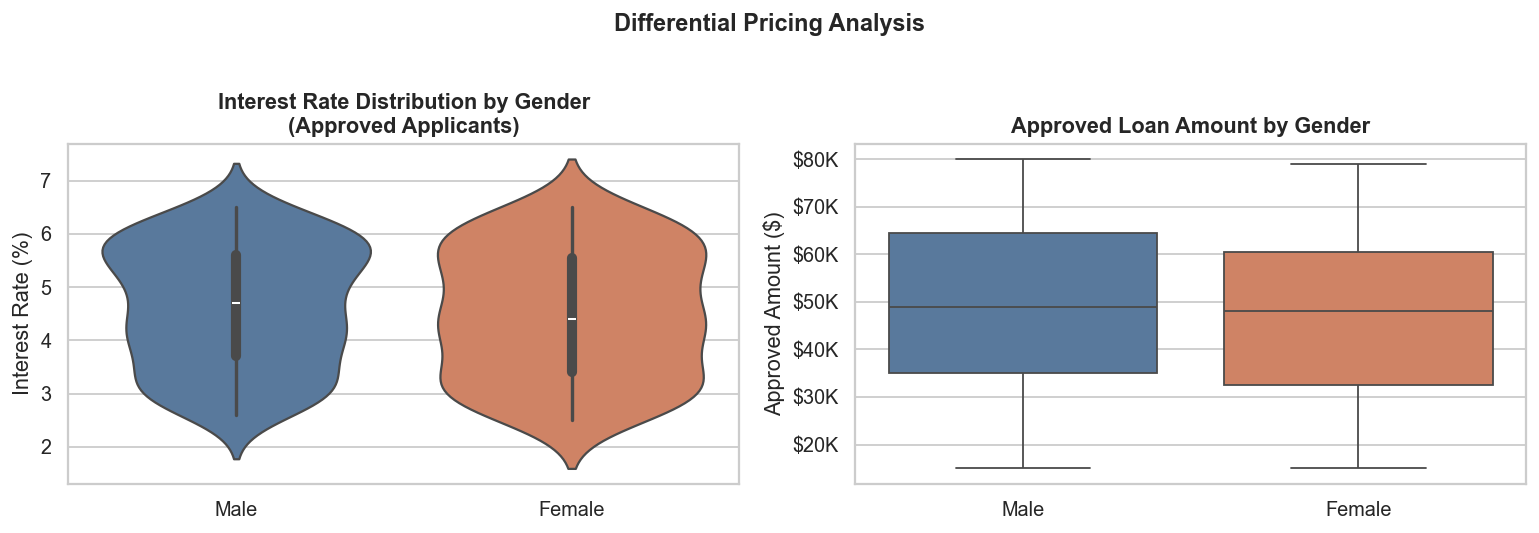

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# violin plot
plot_data = df_approved[['gender','interest_rate']].copy()
sns.violinplot(data=plot_data, x='gender', y='interest_rate',
               palette={'Male':'#4e79a7','Female':'#e07b54'},
               ax=axes[0], inner='box')
axes[0].set_title('Interest Rate Distribution by Gender\n(Approved Applicants)', fontweight='bold')
axes[0].set_ylabel('Interest Rate (%)')
axes[0].set_xlabel('')

# approved amount
df_approved2 = df[
    (df['loan_approved']==True) &
    df['approved_amount'].notna() &
    df['gender'].isin(['Male','Female'])
].copy()

if len(df_approved2) > 0:
    sns.boxplot(data=df_approved2, x='gender', y='approved_amount',
                palette={'Male':'#4e79a7','Female':'#e07b54'},
                ax=axes[1])
    axes[1].set_title('Approved Loan Amount by Gender', fontweight='bold')
    axes[1].set_ylabel('Approved Amount ($)')
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'${y/1000:.0f}K'))
    axes[1].set_xlabel('')

plt.suptitle('Differential Pricing Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/fig_interest_rate_disparity.png', dpi=130)
plt.show()

---
## 7. Sensitive Spending Categories as Proxy Variables

In [31]:
# Rebuild spending flags if loading from CSV (spend_categories is a string in CSV)
if 'has_gambling' not in df.columns:
    if 'spend_categories' in df.columns and isinstance(df['spend_categories'].iloc[0], str):
        import ast
        df['spend_categories_list'] = df['spend_categories'].apply(
            lambda x: ast.literal_eval(x) if pd.notna(x) else []
        )
    elif 'spend_categories' not in df.columns:
        # Re-derive from raw
        with open(RAW_PATH) as f:
            raw2 = json.load(f)
        id_to_cats = {r['_id']: [s.get('category') for s in (r.get('spending_behavior') or [])]
                      for r in raw2}
        df['spend_categories_list'] = df['_id'].map(id_to_cats)
    else:
        df['spend_categories_list'] = df['spend_categories']

    df['has_gambling']  = df['spend_categories_list'].apply(
        lambda c: 'Gambling' in c if isinstance(c, list) else False)
    df['has_alcohol']   = df['spend_categories_list'].apply(
        lambda c: 'Alcohol' in c if isinstance(c, list) else False)
    df['has_sensitive'] = df['has_gambling'] | df['has_alcohol']

# Correlation with protected attributes
print('Sensitive spending categories — presence by gender:')
for cat, col in [('Gambling','has_gambling'),('Alcohol','has_alcohol')]:
    print(f'\n  {cat}:')
    if col in df.columns:
        ct = pd.crosstab(df['gender'], df[col])
        print(ct)
        chi2_c, p_c, _, _ = chi2_contingency(ct)
        print(f'  χ² = {chi2_c:.4f}, p = {p_c:.4f}')

Sensitive spending categories — presence by gender:

  Gambling:
has_gambling  False  True 
gender                    
Female          245      6
Male            247      0
  χ² = 4.1368, p = 0.0420

  Alcohol:
has_alcohol  False  True 
gender                   
Female         248      3
Male           239      8
  χ² = 1.5539, p = 0.2126


In [32]:
# Approval rates with/without sensitive categories
rows = []
for flag, label in [('has_gambling','Gambling'),('has_alcohol','Alcohol'),('has_sensitive','Any Sensitive')]:
    if flag not in df.columns:
        continue
    with_cat    = df[df[flag]==True]['loan_approved'].mean()
    without_cat = df[df[flag]==False]['loan_approved'].mean()
    n_with = df[flag].sum()
    di_cat = with_cat / without_cat if without_cat > 0 else None
    rows.append({'Category': label, 'N with': n_with,
                 'Approval (with)': with_cat, 'Approval (without)': without_cat,
                 'DI Ratio': di_cat})

sensitive_df = pd.DataFrame(rows)
for col in ['Approval (with)','Approval (without)','DI Ratio']:
    sensitive_df[col] = sensitive_df[col].round(4)
print(sensitive_df.to_string(index=False))

     Category  N with  Approval (with)  Approval (without)  DI Ratio
     Gambling       7           0.5714              0.5842    0.9782
      Alcohol      11           0.7273              0.5808    1.2522
Any Sensitive      18           0.6667              0.5809    1.1476


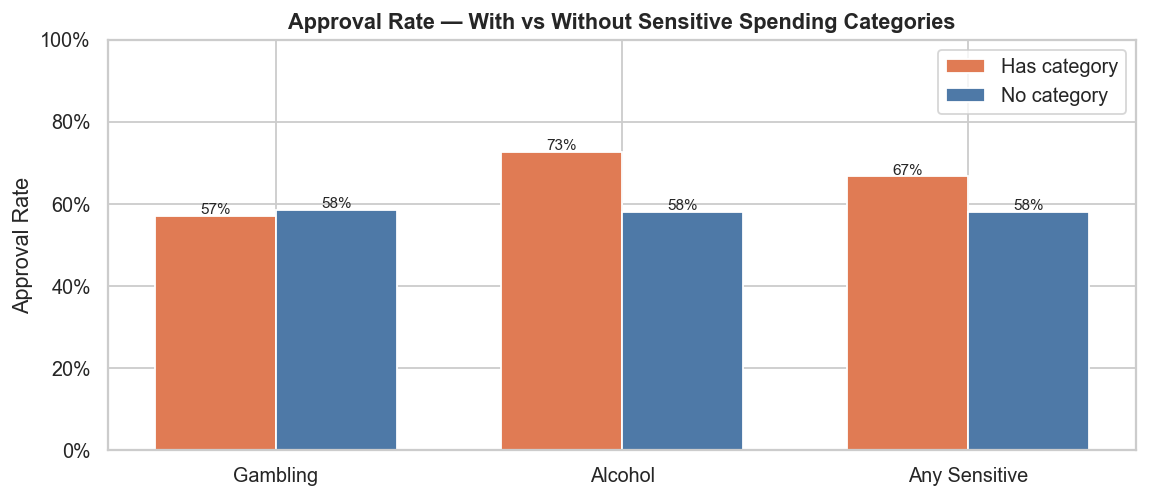

In [33]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(sensitive_df))
w = 0.35
b1 = ax.bar(x - w/2, sensitive_df['Approval (with)'],    w, label='Has category',    color='#e07b54', edgecolor='white')
b2 = ax.bar(x + w/2, sensitive_df['Approval (without)'], w, label='No category',     color='#4e79a7', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(sensitive_df['Category'])
ax.set_ylabel('Approval Rate')
ax.set_title('Approval Rate — With vs Without Sensitive Spending Categories', fontweight='bold')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y*100:.0f}%'))
ax.legend()
for b, v in list(zip(b1, sensitive_df['Approval (with)'])) + list(zip(b2, sensitive_df['Approval (without)'])):
    ax.text(b.get_x()+b.get_width()/2, v+0.005, f'{v*100:.0f}%', ha='center', fontsize=8.5)
plt.tight_layout()
plt.savefig('../data/fig_sensitive_spending.png', dpi=130)
plt.show()

---
## 8. Correlation Heatmap — Feature vs Outcome

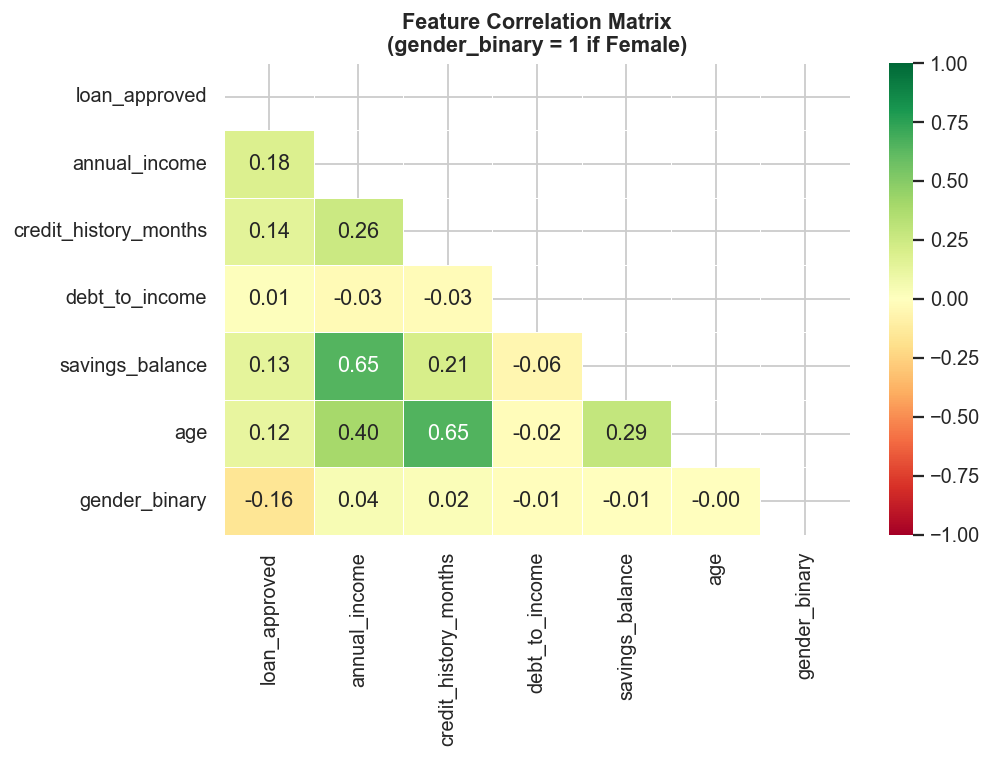


Correlation with loan_approved:
loan_approved            1.000000
annual_income            0.183841
credit_history_months    0.140819
savings_balance          0.133481
age                      0.124126
debt_to_income           0.013370
gender_binary           -0.158932


In [34]:
# Build numeric feature matrix
df_corr = df[[
    'loan_approved','annual_income','credit_history_months',
    'debt_to_income','savings_balance','age'
]].copy()
df_corr['loan_approved'] = df_corr['loan_approved'].astype(float)
df_corr['gender_binary'] = (df['gender'] == 'Female').astype(float)

corr_matrix = df_corr.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Feature Correlation Matrix\n(gender_binary = 1 if Female)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/fig_correlation_heatmap.png', dpi=130)
plt.show()

print('\nCorrelation with loan_approved:')
print(corr_matrix['loan_approved'].sort_values(ascending=False).to_string())

---
## 9. Consolidated Bias Findings Summary

In [35]:
# Re-derive key stats for clean summary output
summary_data = [
    {
        'Bias Type'     : 'Gender Disparate Impact',
        'Metric'        : f'DI = {DI_RATIO:.4f}',
        'Threshold'     : 'DI < 0.8',
        'Triggered?'    : '⚠ YES' if DI_RATIO < 0.8 else '✓ No',
        'p-value'       : f'{p_val:.4f}',
        'Severity'      : 'HIGH' if DI_RATIO < 0.8 and p_val < 0.05 else 'MEDIUM',
    },
    {
        'Bias Type'     : 'Age Bias (18–29 vs 30–39)',
        'Metric'        : f'DI = {di_age_young:.4f}',
        'Threshold'     : 'DI < 0.8',
        'Triggered?'    : '⚠ YES' if di_age_young < 0.8 else '✓ No',
        'p-value'       : f'{p_pb:.4f}',
        'Severity'      : 'HIGH' if di_age_young < 0.8 and p_pb < 0.05 else 'MEDIUM',
    },
    {
        'Bias Type'     : 'ZIP Code Proxy (Geographic)',
        'Metric'        : f'DI = {di_zip:.4f}' if 'di_zip' in dir() else 'N/A',
        'Threshold'     : 'DI < 0.8',
        'Triggered?'    : '⚠ YES' if ('di_zip' in dir() and di_zip < 0.8) else '✓ No',
        'p-value'       : f'{p_zip:.4f}' if 'p_zip' in dir() else 'N/A',
        'Severity'      : 'MEDIUM',
    },
    {
        'Bias Type'     : 'Interest Rate Disparity',
        'Metric'        : f'Median gap = {abs(male_rates_ir.median()-female_rates_ir.median()):.2f}%',
        'Threshold'     : 'p < 0.05',
        'Triggered?'    : '⚠ YES' if p_ir < 0.05 else '✓ No',
        'p-value'       : f'{p_ir:.4f}',
        'Severity'      : 'HIGH' if p_ir < 0.05 else 'LOW',
    },
    {
        'Bias Type'     : 'Sensitive Spending Proxy',
        'Metric'        : 'Category used in decision',
        'Threshold'     : 'Governance policy',
        'Triggered?'    : '⚠ YES',
        'p-value'       : 'N/A',
        'Severity'      : 'HIGH',
    },
]

bias_summary = pd.DataFrame(summary_data)
print('=== BIAS AUDIT SUMMARY ===')
print(bias_summary.to_string(index=False))

=== BIAS AUDIT SUMMARY ===
                  Bias Type                    Metric         Threshold Triggered? p-value Severity
    Gender Disparate Impact               DI = 0.7667          DI < 0.8      ⚠ YES  0.0007     HIGH
  Age Bias (18–29 vs 30–39)               DI = 0.6758          DI < 0.8      ⚠ YES  0.0056     HIGH
ZIP Code Proxy (Geographic)               DI = 0.8016          DI < 0.8       ✓ No  0.0059   MEDIUM
    Interest Rate Disparity        Median gap = 0.30%          p < 0.05       ✓ No  0.3264      LOW
   Sensitive Spending Proxy Category used in decision Governance policy      ⚠ YES     N/A     HIGH


---
## 10. Governance Recommendations

### Recommended Interventions

| Finding | Risk | Recommended Intervention |
|---------|------|---------------------------|
| Gender DI < 0.8 | **CRITICAL** | Remove gender from feature set; apply adversarial debiasing; implement pre-deployment DI testing in CI/CD pipeline |
| Age-based approval disparity | **HIGH** | Age is a protected attribute (ECOA); remove from direct feature set; audit correlation with proxy features |
| ZIP code as proxy | **HIGH** | ZIP codes may proxy race/ethnicity (redlining); use census-level socioeconomic features instead; conduct geographic fairness audits quarterly |
| Gambling/Alcohol in decisions | **HIGH** | Remove from feature set entirely; may proxy religion, disability, and cultural background |
| Interest rate disparity | **MEDIUM** | Audit pricing algorithm separately; implement parity constraints on approved rates |
| All rejections via `algorithm_risk_score` | **MEDIUM** | 82% of denials lack human-interpretable reason; violates explainability requirements of EU AI Act Article 13 |

